# Idea: Exploratory Data Analysis (EDA) on Retail Sales Data

## Key Concepts and Challenges:

### Data Loading and Cleaning: Load the retail sales dataset.
### Descriptive Statistics: Calculate basic statistics (mean, median, mode, standard deviation).
### Time Series Analysis: Analyze sales trends over time using time series techniques.
### Customer and Product Analysis: Analyze customer demographics and purchasing behavior.
### Visualization: Present insights through bar charts, line plots, and heatmaps.
### Recommendations: Provide actionable recommendations based on the EDA.


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline 
import datetime 

In [2]:
df = pd.read_csv('/Users/mahdeeahmed/Documents/Oasis Infobyte/retail_sales_dataset.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


### Descriptive Statistics: Calculate basic statistics (mean, median, mode, standard deviation).

In [3]:
df.describe()

,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000256,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [4]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


In [190]:
df.nunique()

Date                 345
Customer ID         1000
Gender                 2
Age                   47
Product Category       3
Quantity               4
Price per Unit         5
Total Amount          18
age_group             10
dtype: int64

### Time Series Analysis: Analyze sales trends over time using time series techniques.

In [6]:
df.sort_values('Date',inplace=True)
# df.set_index(df['Date'],inplace=True)
df.drop(['Transaction ID'],axis=1,inplace=True)

In [7]:
time_series= df.groupby('Date')['Total Amount'].sum()
time_series

Date
2023-01-01    3600
2023-01-02    1765
2023-01-03     600
2023-01-04    1240
2023-01-05    1100
              ... 
2023-12-27     700
2023-12-28    2075
2023-12-29    3400
2023-12-31      50
2024-01-01    1530
Name: Total Amount, Length: 345, dtype: int64

In [8]:
time_series_mean= time_series.mean()
time_series_mean

1321.7391304347825

In [9]:
rolling_mean= time_series.rolling(window=30).mean()
rolling_mean

Date
2023-01-01            NaN
2023-01-02            NaN
2023-01-03            NaN
2023-01-04            NaN
2023-01-05            NaN
                 ...     
2023-12-27    1394.666667
2023-12-28    1450.833333
2023-12-29    1503.333333
2023-12-31    1489.666667
2024-01-01    1537.000000
Name: Total Amount, Length: 345, dtype: float64

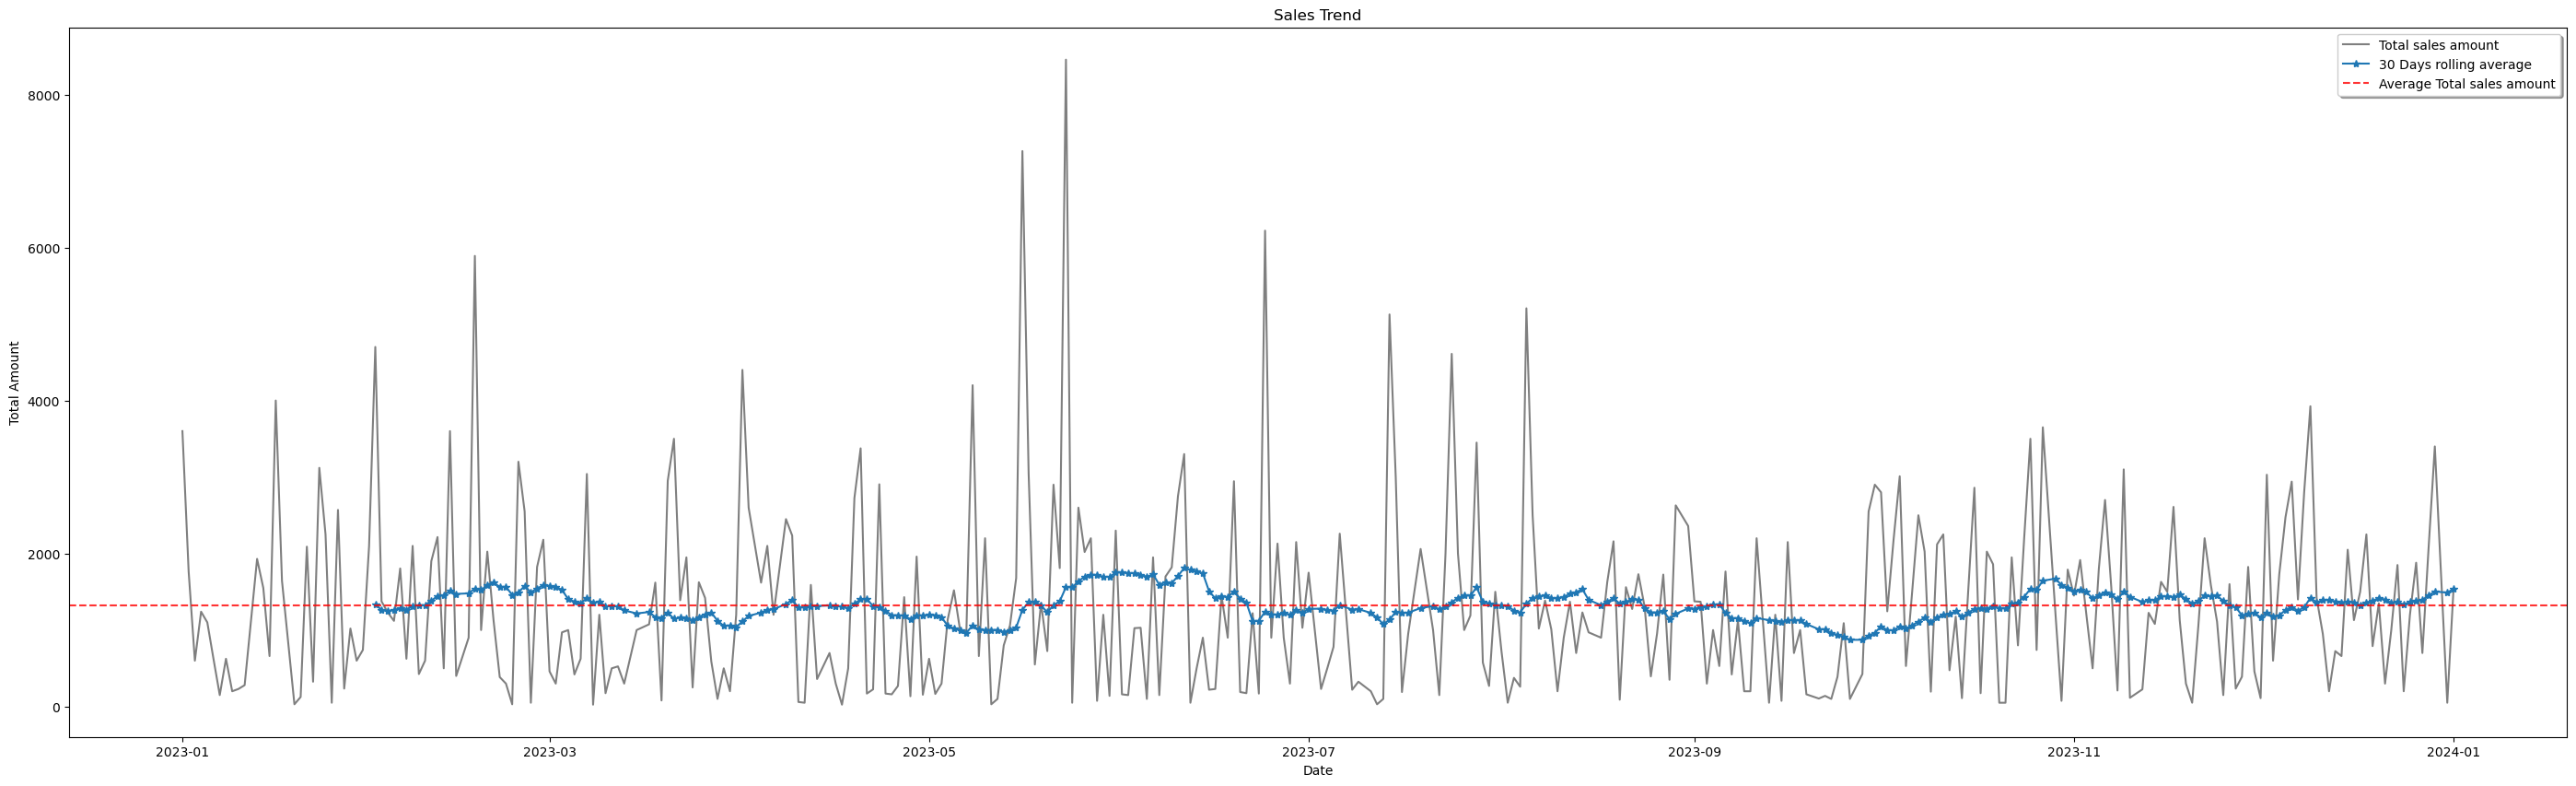

In [10]:
plt.figure(figsize=[35,10])

plt.plot(time_series.index,time_series.values,linestyle='-',color='black',alpha=.5,label = 'Total sales amount')
plt.plot(rolling_mean,marker='*',label = '30 Days rolling average')
plt.axhline(time_series_mean,linestyle = '--',color='r',alpha=.8,label = 'Average Total sales amount')

plt.title('Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Amount')

plt.legend(shadow=True)

### After plotting the mean and rolling mean line, we can see a fluctuation in the sales amount within 30 days period indicating a seasonal trend  or random fluctuations.

### Customer and Product Analysis: Analyze customer demographics and purchasing behavior.


In [11]:
df

,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
521,2023-01-01,CUST522,Male,46,Beauty,3,500,1500
179,2023-01-01,CUST180,Male,41,Clothing,3,300,900
558,2023-01-01,CUST559,Female,40,Clothing,4,300,1200
302,2023-01-02,CUST303,Male,19,Electronics,3,30,90
978,2023-01-02,CUST979,Female,19,Beauty,1,25,25
...,...,...,...,...,...,...,...,...
232,2023-12-29,CUST233,Female,51,Beauty,2,300,600
804,2023-12-29,CUST805,Female,30,Beauty,3,500,1500
856,2023-12-31,CUST857,Male,60,Electronics,2,25,50
210,2024-01-01,CUST211,Male,42,Beauty,3,500,1500


In [80]:
# Age group creation 

start_age = df['Age'].min()
end_age = df['Age'].max()
bins = list(range(start_age,  end_age+5 ,5))

df['age_group'] = pd.cut(df['Age'],bins=bins)
df

,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,age_group
521,2023-01-01,CUST522,Male,46,Beauty,3,500,1500,"(43, 48]"
179,2023-01-01,CUST180,Male,41,Clothing,3,300,900,"(38, 43]"
558,2023-01-01,CUST559,Female,40,Clothing,4,300,1200,"(38, 43]"
302,2023-01-02,CUST303,Male,19,Electronics,3,30,90,"(18, 23]"
978,2023-01-02,CUST979,Female,19,Beauty,1,25,25,"(18, 23]"
...,...,...,...,...,...,...,...,...,...
232,2023-12-29,CUST233,Female,51,Beauty,2,300,600,"(48, 53]"
804,2023-12-29,CUST805,Female,30,Beauty,3,500,1500,"(28, 33]"
856,2023-12-31,CUST857,Male,60,Electronics,2,25,50,"(58, 63]"
210,2024-01-01,CUST211,Male,42,Beauty,3,500,1500,"(38, 43]"


# Finding out the top 3 age group with gender for product category

In [97]:
demographics = df.groupby(['Gender','age_group','Product Category'],observed=False)['Total Amount'].sum().reset_index()
demographics

,Gender,age_group,Product Category,Total Amount
0,Female,"(18, 23]",Beauty,7665
1,Female,"(18, 23]",Clothing,7025
2,Female,"(18, 23]",Electronics,11540
3,Female,"(23, 28]",Beauty,5890
4,Female,"(23, 28]",Clothing,14220
5,Female,"(23, 28]",Electronics,5245
6,Female,"(28, 33]",Beauty,7085
7,Female,"(28, 33]",Clothing,4480
8,Female,"(28, 33]",Electronics,4630
9,Female,"(33, 38]",Beauty,11750


In [91]:
top_3_each_cat = demographics.sort_values(['Product Category','Total Amount'],ascending=[True,False]).groupby('Product Category').head(3)
top_3_each_cat

,Gender,age_group,Product Category,Total Amount
45,Male,"(43, 48]",Beauty,14250
30,Male,"(18, 23]",Beauty,13395
9,Female,"(33, 38]",Beauty,11750
4,Female,"(23, 28]",Clothing,14220
37,Male,"(28, 33]",Clothing,11970
16,Female,"(43, 48]",Clothing,9645
56,Male,"(58, 63]",Electronics,17755
11,Female,"(33, 38]",Electronics,14220
50,Male,"(48, 53]",Electronics,12660


# Finding put top 1 using .idx method 

In [85]:
idx = demographics.groupby('Product Category')['Total Amount'].idxmax()
top_1 = demographics.loc[idx]
top_1

,Gender,age_group,Product Category,Total Amount
45,Male,"(43, 48]",Beauty,14250
4,Female,"(23, 28]",Clothing,14220
56,Male,"(58, 63]",Electronics,17755


# Visualization: Present insights through bar charts, line plots, and heatmaps.


### Bar Charts

In [135]:
age_wise_sales = df.groupby(['Gender','Age'])['Total Amount'].sum().reset_index()
age_wise_sales

,Gender,Age,Total Amount
0,Female,18,7940
1,Female,19,7335
2,Female,20,5175
3,Female,21,5400
4,Female,22,5425
...,...,...,...
89,Male,60,3930
90,Male,61,3890
91,Male,62,5060
92,Male,63,8045


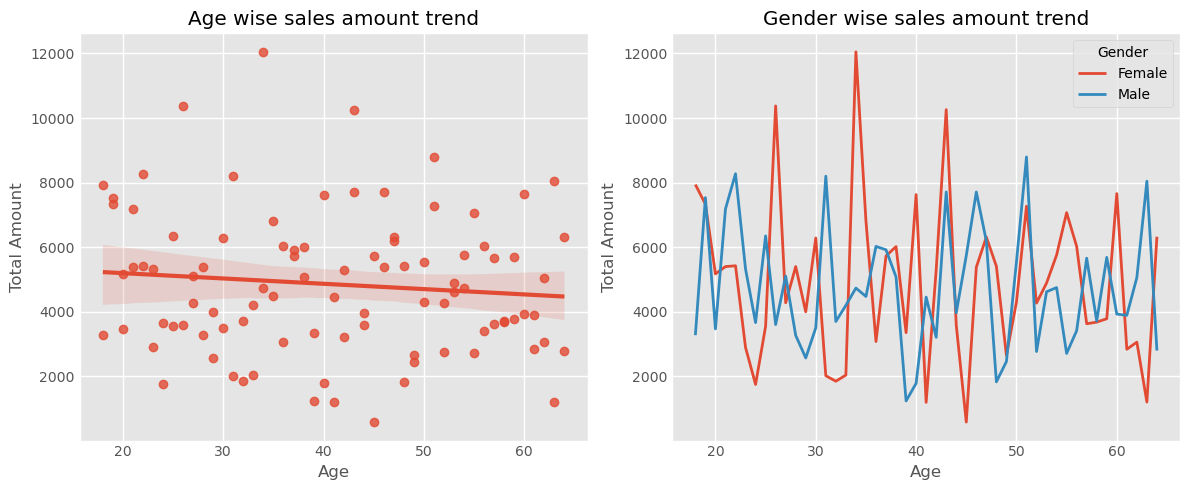

In [189]:
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=[12,5])


sns.regplot(age_wise_sales,x='Age',y='Total Amount',ax=ax[0])
sns.lineplot(age_wise_sales,x='Age',y='Total Amount',ax=ax[1],hue='Gender')



ax[0].set_title('Age wise sales amount trend')
ax[1].set_title('Gender wise sales amount trend')
plt.tight_layout()

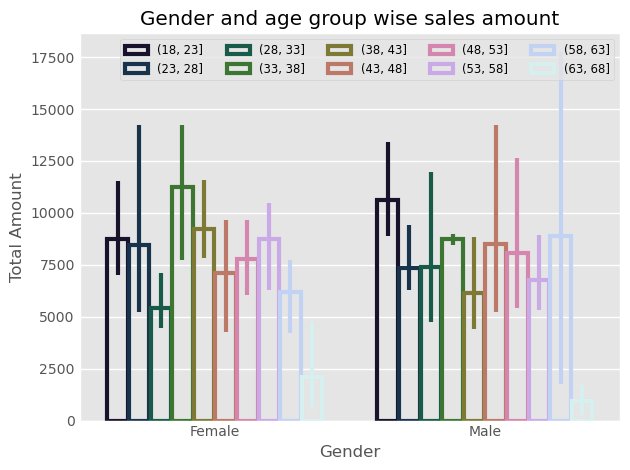

In [265]:
sns.barplot(demographics,x='Gender',y='Total Amount',hue='age_group',palette='cubehelix',fill=False,gap=.05)

plt.legend(loc=1,ncols = 5,fontsize = 'small')
plt.title('Gender and age group wise sales amount')
plt.tight_layout()